<a href="https://colab.research.google.com/github/TakaNori999/ML_Class/blob/main/CNN_origiral_img(Grad_CAM%2B%2B).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title モジュールの作成
# モジュール
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.utils import to_categorical
import os, glob
from PIL import Image

# データのダウンロード
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = (X_train.astype("float32") / 255.0)[..., None]  # (N,28,28,1)
X_test  = (X_test.astype("float32")  / 255.0)[..., None]
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

In [ ]:
#@title 中間層の構成
# 中間層の構成
UNITS_COV1 = 32 #@param {type:"slider", min:32, max:128, step:32}
UNITS_COV2 = 0 #@param {type:"slider", min:0, max:128, step:32}
UNITS_COV3 = 0 #@param {type:"slider", min:0, max:128, step:32}
UNITS_COV4 = 0 #@param {type:"slider", min:0, max:128, step:32}
UNITS_COV5 = 0 #@param {type:"slider", min:0, max:128, step:32}

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inp (InputLayer)                │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc (Dense)                      │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Activation)            │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,680,554 (6.41 MB)

 Trainable params: 1,680,554 (6.41 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.7823 - loss: 0.7329 - val_accuracy: 0.9646 - val_loss: 0.1096
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9681 - loss: 0.1061 - val_accuracy: 0.9783 - val_loss: 0.0654
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9803 - loss: 0.0632 - val_accuracy: 0.9809 - val_loss: 0.0575
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9850 - loss: 0.0461 - val_accuracy: 0.9843 - val_loss: 0.0455
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9904 - loss: 0.0329 - val_accuracy: 0.9840 - val_loss: 0.0514
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9920 - loss: 0.0253 - val_accuracy: 0.9866 - val_loss: 0.0440
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9944 - loss: 0.0201 - val_accuracy: 0.9852 - val_loss: 0.0454
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9954 - loss: 0

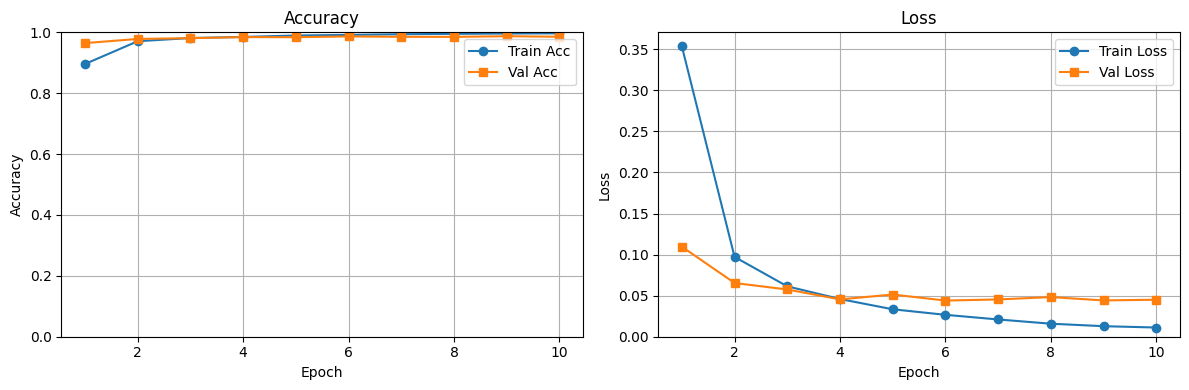

In [ ]:
#@title 学習モデルのトレーニング
EPOCHS = 1 #@param {type:"slider", min:1, max:20, step:1}

# CNN（空間サイズを維持：pooling無し, stride=1, same）
inputs = tf.keras.Input(shape=(28,28,1), name="inp")
x = tf.keras.layers.Conv2D(UNITS_COV1, (3,3), padding="same", activation="relu", name="conv1")(inputs)
if UNITS_COV2 > 0:
  x = tf.keras.layers.Conv2D(UNITS_COV2, (3,3), padding="same", activation="relu", name="conv2")(x)
  # x = tf.keras.layers.MaxPooling2D((2,2))(x)
if UNITS_COV3 > 0:
  x = tf.keras.layers.Conv2D(UNITS_COV3, (3,3), padding="same", activation="relu", name="conv3")(x)
  # x = tf.keras.layers.MaxPooling2D((2,2))(x)
if UNITS_COV4 > 0:
  x = tf.keras.layers.Conv2D(UNITS_COV4, (3,3), padding="same", activation="relu", name="conv4")(x)
if UNITS_COV5 > 0:
  x = tf.keras.layers.Conv2D(UNITS_COV5, (3,3), padding="same", activation="relu", name="conv5")(x)
x = tf.keras.layers.Flatten(name="flatten")(x)
x = tf.keras.layers.Dense(64, activation="relu", name="fc")(x)
logits = tf.keras.layers.Dense(10, name="logits")(x)
outputs = tf.keras.layers.Activation("softmax", name="softmax")(logits)
model = tf.keras.Model(inputs, outputs)
model.compile(optimizer="SGD", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

history = model.fit(X_train, y_train, epochs=EPOCHS, batch_size=32, verbose=1, validation_data=(X_test, y_test))
test_acc = model.evaluate(X_test, y_test, verbose=0)[1]
print("Test ACC:", test_acc)


# 学習履歴の表示
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# --- Accuracy ---
ax[0].plot(epochs, acc, marker='o', label='Train Acc')
ax[0].plot(epochs, val_acc, marker='s', label='Val Acc')
ax[0].set_title('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].set_ylim(0, 1.0)
ax[0].grid(True)
ax[0].legend()

# --- Loss ---
ax[1].plot(epochs, loss, marker='o', label='Train Loss')
ax[1].plot(epochs, val_loss, marker='s', label='Val Loss')
ax[1].set_title('Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].set_ylim(0, None)
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
#@title テスト画像の表示
# original imgリポジトリから取得
!rm -rf Num_sorce_mnist
!git clone https://github.com/TakaNori999/Num_sorce_mnist.git

data_dir = "/content/Num_sorce_mnist/num_src"

img_paths = sorted(glob.glob(os.path.join(data_dir, "*.*")))
X_ext_model = []
y_ext = []                # 正解ラベル
imgs_ext_show = []        # 表示用：オリジナル（白背景・黒文字）

def gradcampp_for_layer(model, img4d, layer_name, eps=1e-8):
    target = model.get_layer(layer_name)
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[target.output, model.get_layer('logits').output]
    )

    with tf.GradientTape() as tape:
        fmap, logits = grad_model(img4d, training=False)          # fmap: (1,h,w,k)
        class_idx = tf.argmax(logits[0])
        score = logits[:, class_idx]                               # y^c

    grads = tape.gradient(score, fmap)                             # (1,h,w,k)
    fmap  = fmap[0]                                                # (h,w,k)
    grads = grads[0]                                               # (h,w,k)

    grads2 = tf.square(grads)                                      # g^2
    grads3 = grads2 * grads                                        # g^3
    alpha_num   = grads2
    alpha_denom = 2.0 * grads2 + fmap * grads3 + eps               # 2g^2 + A*g^3 + ε
    alpha = alpha_num / alpha_denom                                # (h,w,k)

    positive_grads = tf.nn.relu(grads)                             # ReLU(g)
    weights = tf.reduce_sum(alpha * positive_grads, axis=[0,1])    # w_k = Σ_ij α_ij ReLU(g_ij)

    cam = tf.reduce_sum(fmap * weights, axis=-1)                   # Σ_k w_k A^k
    cam = tf.nn.relu(cam).numpy()

    if cam.max() > 0:
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    H, W = img4d.shape[1], img4d.shape[2]
    cam = tf.image.resize(cam[..., None], (H, W)).numpy().squeeze()
    return cam, int(class_idx)

def load_external_image(path):
    img = Image.open(path).convert("L")
    img = img.resize((28, 28))
    img_arr = np.array(img).astype("float32") / 255.0
    return img_arr

def preprocess_for_model(img_arr):
    return 1.0 - img_arr

for path in img_paths:
    fname = os.path.basename(path)

    label = int(fname[0])
    img_orig = load_external_image(path)        # 表示用（白背景・黒文字）
    img_model = preprocess_for_model(img_orig)  # 予測用（黒背景・白文字）

    imgs_ext_show.append(img_orig)
    X_ext_model.append(img_model)
    y_ext.append(label)

X_ext_model = np.array(X_ext_model, dtype="float32")[..., None]
y_ext_cat   = to_categorical(y_ext, 10)


ext_loss, ext_acc = model.evaluate(X_ext_model, y_ext_cat, verbose=0)

gallery_map_ext = {i: idx for i, idx in enumerate(range(len(imgs_ext_show)))}

rows, cols = 5, 6
plt.figure(figsize=(2*cols, 2*rows))
for i, img_arr in enumerate(imgs_ext_show):
    plt.subplot(rows, cols, i+1)
    plt.imshow(img_arr, cmap='gray')
    plt.axis("off")
    plt.title(f"#{i}", fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
#@title 未知画像の予測
#@title 外部（オリジナル）画像の未知画像予測＋Grad-CAM++

# 予測するカード番号（ギャラリーの #番号）
INDEXES = [0]  #@param {type:"raw"}

# 対象とする畳み込み層（元のコードと同じロジック）
if UNITS_COV5 > 0:
  TARGET_LAYER = 'conv5'
elif UNITS_COV4 > 0:
  TARGET_LAYER = 'conv4'
elif UNITS_COV3 > 0:
  TARGET_LAYER = 'conv3'
elif UNITS_COV2 > 0:
  TARGET_LAYER = 'conv2'
else:
  TARGET_LAYER = 'conv1'

plt.figure(figsize=(10, 3*len(INDEXES)))
for r, local_id in enumerate(INDEXES, start=1):

    if local_id not in gallery_map_ext:
        print(f"⚠ INDEXES に指定した {local_id} は範囲外です（0〜{len(imgs_ext_show)-1}）。")
        continue

    idx = gallery_map_ext[local_id]

    # 表示用（オリジナル：白背景・黒文字）
    img_show = imgs_ext_show[idx]

    # モデル入力用（MNIST と同じ向き：黒背景・白文字）
    img4d = X_ext_model[idx:idx+1]   # shape (1,28,28,1)

    # 予測
    prob = model.predict(img4d, verbose=0)[0]
    pred = int(np.argmax(prob))
    conf = float(np.max(prob))

    # Grad-CAM++
    heat, _ = gradcampp_for_layer(model, img4d, TARGET_LAYER)

    # 1列目：オリジナル画像
    plt.subplot(len(INDEXES), 3, 3*r-2)
    plt.imshow(img_show, cmap='gray')
    plt.axis('off')
    plt.title(f"#{local_id}")

    # 2列目：オリジナル＋ヒートマップ
    plt.subplot(len(INDEXES), 3, 3*r-1)
    plt.imshow(img_show, cmap='gray')
    plt.imshow(heat, cmap='jet', alpha=0.5)
    plt.axis('off')
    plt.title(f"pred={pred}, p={conf:.3f}")

plt.tight_layout()
plt.show()